# RQ2 Anomaly Detection Notebook

**RQ2:** Can unsupervised methods like Isolation Forest and LSTM Autoencoder detect anomalous VM behavior such as spikes, dips, and dead VMs with higher F1 score than a rolling three-sigma thresholding rule, using synthetic anomaly injection as ground truth?

Main correction: Isolation Forest should not rely directly on `predict()` with a fixed contamination value. It should use anomaly scores from `decision_function()`, tune a threshold on validation anomalies, and then evaluate on the final test set.

## 1. Imports and Configuration

Load the required packages and define the data path, output path, split boundaries, and CPU column names. The split is chronological to avoid look-ahead leakage.

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from sklearn.preprocessing import RobustScaler, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/processed/hourly_n2000.parquet"
OUTPUT_DIR = "../data/reports/rq2_anomaly_detection"

if not os.path.exists(DATA_PATH):
    alt_path = "data/processed/hourly_n2000.parquet"
    if os.path.exists(alt_path):
        DATA_PATH = alt_path

if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = "data/reports/rq2_anomaly_detection"

os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_END = 503
VAL_END = 599
TEST_END = 719

CPU_MEAN = "avg_cpu_mean"
CPU_MAX = "avg_cpu_max"
CPU_MIN = "avg_cpu_min"
CPU_STD = "avg_cpu_std"

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_PATH: ../data/processed/hourly_n2000.parquet
OUTPUT_DIR: ../data/reports/rq2_anomaly_detection


## 2. Load and Validate Data

The processed hourly dataset must contain the RQ2 data dictionary fields. This cell validates required columns, duplicate VM-hour rows, and CPU numeric types.

In [3]:
def load_data(path=DATA_PATH):
    df = pd.read_parquet(path)
    df = df.sort_values(["vm_id", "hour_index"]).reset_index(drop=True)

    required_cols = [
        "vm_id", "hour_index", CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD,
        "hour_of_day", "day_index", "day_of_cycle"
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    duplicate_count = df.duplicated(["vm_id", "hour_index"]).sum()
    if duplicate_count > 0:
        raise ValueError(f"Duplicate VM-hour rows found: {duplicate_count}")

    for col in [CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD]:
        df[col] = df[col].astype("float64")

    print("Shape:", df.shape)
    print("Unique VMs:", df["vm_id"].nunique())
    print("Unique hours:", df["hour_index"].nunique())
    print("Missing values:")
    print(df[required_cols].isna().sum())
    return df


## 3. Synthetic Anomaly Injection

The Azure trace has no real incident labels. This function injects controlled synthetic anomalies into validation and test splits only. Training remains clean so the models learn normal behavior.

In [4]:
def _fix_cpu_consistency(df, indices):
    for col in [CPU_MEAN, CPU_MAX, CPU_MIN]:
        df.loc[indices, col] = df.loc[indices, col].clip(0, 100)
    df.loc[indices, CPU_STD] = df.loc[indices, CPU_STD].clip(lower=0)

    mean_vals = df.loc[indices, CPU_MEAN].to_numpy()
    min_vals = df.loc[indices, CPU_MIN].to_numpy()
    max_vals = df.loc[indices, CPU_MAX].to_numpy()
    df.loc[indices, CPU_MIN] = np.minimum(min_vals, mean_vals)
    df.loc[indices, CPU_MAX] = np.maximum(max_vals, mean_vals)


def _inject_sustained_spike(df, indices, rng):
    duration = len(indices)
    new_mean = rng.uniform(80, 98, duration) + rng.normal(0, 2, duration)
    df.loc[indices, CPU_MEAN] = np.clip(new_mean, 0, 100)
    df.loc[indices, CPU_MAX] = np.clip(new_mean + rng.uniform(2, 8, duration), 0, 100)
    df.loc[indices, CPU_MIN] = np.clip(new_mean - rng.uniform(3, 12, duration), 0, 100)
    df.loc[indices, CPU_STD] = rng.uniform(2, 8, duration)


def _inject_sustained_dip(df, indices, rng):
    duration = len(indices)
    original = df.loc[indices, CPU_MEAN].to_numpy()
    new_mean = original * rng.uniform(0.03, 0.20) + rng.normal(0, 0.5, duration)
    df.loc[indices, CPU_MEAN] = np.clip(new_mean, 0, 100)
    df.loc[indices, CPU_MAX] = np.clip(new_mean + rng.uniform(0.5, 3, duration), 0, 100)
    df.loc[indices, CPU_MIN] = np.clip(new_mean - rng.uniform(0.1, 1, duration), 0, 100)
    df.loc[indices, CPU_STD] = rng.uniform(0.1, 1.5, duration)


def _inject_dead_vm(df, indices, rng):
    duration = len(indices)
    new_mean = rng.uniform(0.0, 1.0, duration)
    df.loc[indices, CPU_MEAN] = new_mean
    df.loc[indices, CPU_MAX] = np.clip(new_mean + rng.uniform(0.0, 0.8, duration), 0, 100)
    df.loc[indices, CPU_MIN] = rng.uniform(0.0, 0.2, duration)
    df.loc[indices, CPU_STD] = rng.uniform(0.0, 0.3, duration)


def _inject_gradual_degradation(df, indices, rng):
    duration = len(indices)
    original = df.loc[indices, CPU_MEAN].to_numpy()
    trend = np.linspace(rng.uniform(1.2, 1.6), rng.uniform(3.5, 6.0), duration)
    new_mean = original * trend + rng.normal(0, 2, duration)
    df.loc[indices, CPU_MEAN] = np.clip(new_mean, 0, 100)
    df.loc[indices, CPU_MAX] = np.clip(new_mean + rng.uniform(2, 10, duration), 0, 100)
    df.loc[indices, CPU_MIN] = np.clip(new_mean - rng.uniform(2, 10, duration), 0, 100)
    df.loc[indices, CPU_STD] = rng.uniform(2, 9, duration)


def _inject_cpu_freeze(df, indices, rng):
    duration = len(indices)
    freeze_value = float(df.loc[indices[0], CPU_MEAN])
    new_mean = np.clip(freeze_value + rng.normal(0, 0.03, duration), 0, 100)
    df.loc[indices, CPU_MEAN] = new_mean
    df.loc[indices, CPU_MAX] = np.clip(new_mean + rng.uniform(0.0, 0.3, duration), 0, 100)
    df.loc[indices, CPU_MIN] = np.clip(new_mean - rng.uniform(0.0, 0.3, duration), 0, 100)
    df.loc[indices, CPU_STD] = rng.uniform(0.0, 0.15, duration)


def _inject_cpu_flapping(df, indices, rng):
    duration = len(indices)
    low_values = rng.uniform(2, 15, duration)
    high_values = rng.uniform(75, 98, duration)
    pattern = np.where(np.arange(duration) % 2 == 0, low_values, high_values)
    new_mean = np.clip(pattern + rng.normal(0, 2, duration), 0, 100)
    df.loc[indices, CPU_MEAN] = new_mean
    df.loc[indices, CPU_MAX] = np.clip(new_mean + rng.uniform(2, 8, duration), 0, 100)
    df.loc[indices, CPU_MIN] = np.clip(new_mean - rng.uniform(2, 8, duration), 0, 100)
    df.loc[indices, CPU_STD] = rng.uniform(5, 18, duration)


def _inject_contextual_spike(df, indices, rng):
    duration = len(indices)
    original = df.loc[indices, CPU_MEAN].to_numpy()
    new_mean = original + rng.uniform(20, 45) + rng.normal(0, 2, duration)
    df.loc[indices, CPU_MEAN] = np.clip(new_mean, 0, 100)
    df.loc[indices, CPU_MAX] = np.clip(new_mean + rng.uniform(1, 6, duration), 0, 100)
    df.loc[indices, CPU_MIN] = np.clip(new_mean - rng.uniform(1, 8, duration), 0, 100)
    df.loc[indices, CPU_STD] = rng.uniform(1, 6, duration)


def inject_vm_cpu_anomalies(input_df, anomaly_fraction=0.005, min_duration=3, max_duration=24, random_state=42):
    rng = np.random.default_rng(random_state)
    out = input_df.copy().sort_values(["vm_id", "hour_index"]).reset_index(drop=True)
    out["is_anomaly"] = 0
    out["anomaly_type"] = "normal"
    out["anomaly_event_id"] = -1

    target_rows = max(1, int(len(out) * anomaly_fraction))
    vm_ids = out["vm_id"].dropna().unique()
    anomaly_types = [
        "sustained_spike", "sustained_dip", "dead_vm", "gradual_degradation",
        "cpu_freeze", "cpu_flapping", "contextual_spike"
    ]

    created_rows = 0
    event_id = 0
    events = []
    attempts = 0
    max_attempts = 20000

    while created_rows < target_rows and attempts < max_attempts:
        attempts += 1
        vm = rng.choice(vm_ids)
        vm_indices = out.index[out["vm_id"] == vm].to_numpy()
        if len(vm_indices) < min_duration + 2:
            continue

        duration = int(rng.integers(min_duration, min(max_duration, len(vm_indices)) + 1))
        if len(vm_indices) <= duration:
            continue

        start_pos = int(rng.integers(0, len(vm_indices) - duration))
        event_indices = vm_indices[start_pos:start_pos + duration]
        if out.loc[event_indices, "is_anomaly"].sum() > 0:
            continue

        anomaly_type = str(rng.choice(anomaly_types))
        if anomaly_type == "sustained_spike":
            _inject_sustained_spike(out, event_indices, rng)
        elif anomaly_type == "sustained_dip":
            _inject_sustained_dip(out, event_indices, rng)
        elif anomaly_type == "dead_vm":
            _inject_dead_vm(out, event_indices, rng)
        elif anomaly_type == "gradual_degradation":
            _inject_gradual_degradation(out, event_indices, rng)
        elif anomaly_type == "cpu_freeze":
            _inject_cpu_freeze(out, event_indices, rng)
        elif anomaly_type == "cpu_flapping":
            _inject_cpu_flapping(out, event_indices, rng)
        elif anomaly_type == "contextual_spike":
            _inject_contextual_spike(out, event_indices, rng)

        _fix_cpu_consistency(out, event_indices)
        out.loc[event_indices, "is_anomaly"] = 1
        out.loc[event_indices, "anomaly_type"] = anomaly_type
        out.loc[event_indices, "anomaly_event_id"] = event_id

        events.append({
            "anomaly_event_id": event_id,
            "vm_id": int(vm),
            "start_hour_index": int(out.loc[event_indices[0], "hour_index"]),
            "end_hour_index": int(out.loc[event_indices[-1], "hour_index"]),
            "duration_hours": int(duration),
            "anomaly_type": anomaly_type
        })
        created_rows += duration
        event_id += 1

    events_df = pd.DataFrame(events)
    print("Target anomaly rows:", target_rows)
    print("Created anomaly rows:", int(out["is_anomaly"].sum()))
    print("Created anomaly events:", len(events_df))
    return out, events_df


## 4. Feature Engineering

This cell creates shifted rolling features, VM-relative z-scores, cyclical encodings, and CPU range features. These features make Isolation Forest compare each VM against its own normal behavior instead of relying only on global CPU distributions.

In [5]:
def add_rq2_features(df, train_reference_df=None):
    out = df.copy().sort_values(["vm_id", "hour_index"]).reset_index(drop=True)

    out["hour_sin"] = np.sin(2 * np.pi * out["hour_of_day"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour_of_day"] / 24)
    out["cycle_sin"] = np.sin(2 * np.pi * out["day_of_cycle"] / 7)
    out["cycle_cos"] = np.cos(2 * np.pi * out["day_of_cycle"] / 7)

    grouped = out.groupby("vm_id", group_keys=False)
    for col in [CPU_MEAN, CPU_MAX, CPU_STD]:
        out[f"{col}_lag1"] = grouped[col].shift(1)
        out[f"{col}_lag24"] = grouped[col].shift(24)
        out[f"{col}_diff1"] = out[col] - out[f"{col}_lag1"]
        out[f"{col}_roll_mean_24"] = grouped[col].transform(lambda s: s.shift(1).rolling(24, min_periods=6).mean())
        out[f"{col}_roll_std_24"] = grouped[col].transform(lambda s: s.shift(1).rolling(24, min_periods=6).std())
        out[f"{col}_roll_mean_168"] = grouped[col].transform(lambda s: s.shift(1).rolling(168, min_periods=24).mean())
        out[f"{col}_roll_std_168"] = grouped[col].transform(lambda s: s.shift(1).rolling(168, min_periods=24).std())
        out[f"{col}_z24"] = (out[col] - out[f"{col}_roll_mean_24"]) / out[f"{col}_roll_std_24"].replace(0, np.nan)
        out[f"{col}_z168"] = (out[col] - out[f"{col}_roll_mean_168"]) / out[f"{col}_roll_std_168"].replace(0, np.nan)

    ref = train_reference_df if train_reference_df is not None else out[out["hour_index"] <= TRAIN_END]
    ref_stats = ref.groupby("vm_id")[[CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD]].agg(["mean", "std", "median"])
    ref_stats.columns = ["_".join(c) for c in ref_stats.columns]
    ref_stats = ref_stats.reset_index()
    out = out.merge(ref_stats, on="vm_id", how="left")

    for col in [CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD]:
        out[f"{col}_train_z"] = (out[col] - out[f"{col}_mean"]) / out[f"{col}_std"].replace(0, np.nan)
        out[f"{col}_train_delta_median"] = out[col] - out[f"{col}_median"]

    out["cpu_range"] = out[CPU_MAX] - out[CPU_MIN]
    out["max_minus_mean"] = out[CPU_MAX] - out[CPU_MEAN]
    out["mean_minus_min"] = out[CPU_MEAN] - out[CPU_MIN]
    return out


## 5. Evaluation Helpers

These functions calculate precision, recall, F1, confusion matrix counts, threshold tuning by validation F1, MTTD, and anomaly-type metrics.

In [6]:
def evaluate_binary(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else np.nan
    }


def tune_threshold_by_f1(
    y_true,
    scores,
    higher_score_more_anomalous=True
):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    valid = np.isfinite(scores)
    y = y_true[valid]
    original_scores = scores[valid]

    if len(y) == 0:
        raise ValueError("No finite scores available.")

    if np.unique(y).size < 2:
        raise ValueError(
            "Validation labels must contain normal and anomaly rows."
        )

    working_scores = (
        original_scores
        if higher_score_more_anomalous
        else -original_scores
    )

    precision, recall, thresholds = precision_recall_curve(
        y,
        working_scores
    )

    f1_values = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )

    best_index = int(np.nanargmax(f1_values))
    working_threshold = float(thresholds[best_index])

    threshold = (
        working_threshold
        if higher_score_more_anomalous
        else -working_threshold
    )

    return {
        "threshold": threshold,
        "f1": float(f1_values[best_index]),
        "precision": float(precision[best_index]),
        "recall": float(recall[best_index]),
        "average_precision": float(
            average_precision_score(y, working_scores)
        )
    }

def calculate_mttd(scored_df, event_df, pred_col="pred_anomaly"):
    delays = []
    rows = []
    if event_df is None or len(event_df) == 0:
        return np.nan, pd.DataFrame()

    for _, event in event_df.iterrows():
        event_id = int(event["anomaly_event_id"])
        vm_id = int(event["vm_id"])
        onset = int(event["start_hour_index"])
        event_rows = scored_df[(scored_df["vm_id"] == vm_id) & (scored_df["anomaly_event_id"] == event_id)]
        detected = event_rows[event_rows[pred_col] == 1]

        if len(detected) == 0:
            first_detection = np.nan
            delay = np.nan
            detected_flag = 0
        else:
            first_detection = int(detected["hour_index"].min())
            delay = first_detection - onset
            detected_flag = 1
            delays.append(delay)

        rows.append({
            "model_pred_col": pred_col,
            "anomaly_event_id": event_id,
            "vm_id": vm_id,
            "anomaly_type": event["anomaly_type"],
            "start_hour_index": onset,
            "first_detection_hour": first_detection,
            "detected": detected_flag,
            "detection_delay_hours": delay
        })

    mean_delay = float(np.mean(delays)) if len(delays) > 0 else np.nan
    return mean_delay, pd.DataFrame(rows)


def per_type_metrics(df, pred_col):
    rows = []
    for anomaly_type in sorted(df.loc[df["is_anomaly"] == 1, "anomaly_type"].unique()):
        sub = df[(df["anomaly_type"] == anomaly_type) | (df["is_anomaly"] == 0)].copy()
        rows.append({
            "anomaly_type": anomaly_type,
            "precision": precision_score(sub["is_anomaly"], sub[pred_col], zero_division=0),
            "recall": recall_score(sub["is_anomaly"], sub[pred_col], zero_division=0),
            "f1": f1_score(sub["is_anomaly"], sub[pred_col], zero_division=0),
            "support": int((sub["is_anomaly"] == 1).sum())
        })
    return pd.DataFrame(rows)


## 6. Rolling Three-Sigma Baseline

The baseline flags anomalies where shifted rolling CPU z-scores exceed plus or minus three standard deviations.

In [7]:
def three_sigma_predict(feature_df):
    z_mean = feature_df[f"{CPU_MEAN}_z24"].fillna(feature_df[f"{CPU_MEAN}_z168"])
    z_max = feature_df[f"{CPU_MAX}_z24"].fillna(feature_df[f"{CPU_MAX}_z168"])
    pred = ((z_mean.abs() >= 3.0) | (z_max.abs() >= 3.0)).astype(int)
    return pred


## 7. Isolation Forest

The corrected Isolation Forest uses calibrated scores. `decision_function()` returns higher scores for more normal rows, so the result is multiplied by -1 to make higher values more anomalous.

In [8]:
def run_isolation_forest(train_df, val_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_val = val_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians).fillna(0)
    X_val = X_val.fillna(train_medians).fillna(0)
    X_test = X_test.fillna(train_medians).fillna(0)

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    iso = IsolationForest(
        n_estimators=500,
        contamination="auto",
        max_samples=min(200000, len(X_train)),
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    iso.fit(X_train_scaled)

    val_scores = -iso.decision_function(X_val_scaled)
    test_scores = -iso.decision_function(X_test_scaled)

    best_threshold = tune_threshold_by_f1(
        y_true=val_df["is_anomaly"].values,
        scores=val_scores,
        higher_score_more_anomalous=True
    )
    threshold = best_threshold["threshold"]
    val_pred = (val_scores >= threshold).astype(int)
    test_pred = (test_scores >= threshold).astype(int)

    return {
        "model": iso,
        "scaler": scaler,
        "threshold": threshold,
        "validation_best": best_threshold,
        "val_scores": val_scores,
        "test_scores": test_scores,
        "val_pred": val_pred,
        "test_pred": test_pred
    }


## 8. LSTM Autoencoder

The LSTM Autoencoder learns normal 24-hour sequences and flags sequences with high reconstruction error. If TensorFlow is unavailable, this section skips cleanly.

In [11]:
def build_lstm_sequences(df,value_cols,seq_len=24):
    X=[]; y=[]; keys=[]
    for vm,group in df.sort_values(['vm_id','hour_index']).groupby('vm_id'):
        values=group[value_cols].to_numpy(dtype='float32')
        labels=group['is_anomaly'].to_numpy(dtype='int32')
        hours=group['hour_index'].to_numpy(dtype='int32')
        if len(group)<seq_len: continue
        for end in range(seq_len-1,len(group)):
            start=end-seq_len+1
            X.append(values[start:end+1])
            y.append(int(labels[end]))
            keys.append((int(vm),int(hours[end])))
    return np.asarray(X,dtype='float32'), np.asarray(y,dtype='int32'), keys


def run_lstm_autoencoder(train_df, val_df, test_df, seq_len=24, epochs=15, batch_size=512):
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers
    except Exception as e:
        print("TensorFlow is not available. LSTM Autoencoder skipped.")
        print("Import error:", repr(e))
        return None

    #value_cols = [CPU_MEAN, CPU_MAX, CPU_STD, "hour_sin", "hour_cos", "cycle_sin", "cycle_cos"]
    value_cols = [CPU_MEAN,CPU_MAX,CPU_MIN,CPU_STD,"hour_sin","hour_cos","cycle_sin","cycle_cos"]
    cpu_score_indices = [value_cols.index(CPU_MEAN),value_cols.index(CPU_MAX),value_cols.index(CPU_MIN),value_cols.index(CPU_STD)]
    scaler = StandardScaler()
    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    test_scaled = test_df.copy()

    train_scaled[value_cols] = scaler.fit_transform(train_scaled[value_cols].fillna(0))
    val_scaled[value_cols] = scaler.transform(val_scaled[value_cols].fillna(0))
    test_scaled[value_cols] = scaler.transform(test_scaled[value_cols].fillna(0))

    X_train, _, _ = build_lstm_sequences(train_scaled, value_cols, seq_len=seq_len)
    X_val, y_val_seq, val_keys = build_lstm_sequences(val_scaled, value_cols, seq_len=seq_len)
    X_test, y_test_seq, test_keys = build_lstm_sequences(test_scaled, value_cols, seq_len=seq_len)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        print("Not enough rows to build LSTM sequences. LSTM Autoencoder skipped.")
        return None

    tf.random.set_seed(RANDOM_STATE)
    n_features = X_train.shape[2]

    model = keras.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(32, activation="tanh", return_sequences=False),
        layers.RepeatVector(seq_len),
        layers.LSTM(32, activation="tanh", return_sequences=True),
        layers.TimeDistributed(layers.Dense(n_features))
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")

    normal_val_mask = y_val_seq == 0
    validation_data = (X_val[normal_val_mask], X_val[normal_val_mask]) if normal_val_mask.sum() > 0 else None
    callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

    history = model.fit(
        X_train, X_train,
        validation_data=validation_data,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks
    )

    val_recon = model.predict(X_val, batch_size=batch_size, verbose=0)
    test_recon = model.predict(X_test, batch_size=batch_size, verbose=0)
    val_scores = np.mean((X_val[:, -1, cpu_score_indices] - val_recon[:, -1, cpu_score_indices]) ** 2,axis=1)
    test_scores = np.mean((X_test[:, -1, cpu_score_indices] - test_recon[:, -1, cpu_score_indices]) ** 2,axis=1)

    best_threshold = tune_threshold_by_f1(y_val_seq, val_scores, higher_score_more_anomalous=True)
    threshold = best_threshold["threshold"]
    val_pred_seq = (val_scores >= threshold).astype(int)
    test_pred_seq = (test_scores >= threshold).astype(int)

    test_seq_df = pd.DataFrame(test_keys, columns=["vm_id", "hour_index"])
    test_seq_df["lstm_score"] = test_scores
    test_seq_df["lstm_pred"] = test_pred_seq

    val_seq_df = pd.DataFrame(val_keys, columns=["vm_id", "hour_index"])
    val_seq_df["lstm_score"] = val_scores
    val_seq_df["lstm_pred"] = val_pred_seq

    return {
        "model": model,
        "scaler": scaler,
        "threshold": threshold,
        "validation_best": best_threshold,
        "history": history,
        "val_seq_df": val_seq_df,
        "test_seq_df": test_seq_df,
        "y_val_seq": y_val_seq,
        "y_test_seq": y_test_seq,
        "val_scores": val_scores,
        "test_scores": test_scores,
        "val_pred_seq": val_pred_seq,
        "test_pred_seq": test_pred_seq,
        "value_cols": value_cols
    }


## 9. Run the Complete RQ2 Pipeline

This cell executes the full workflow and saves all outputs for the final report. If the notebook is imported rather than run interactively, call `run_rq2_pipeline()` manually.

In [13]:
def run_rq2_pipeline():
    df = load_data(DATA_PATH)

    clean_train = df[df["hour_index"] <= TRAIN_END].copy()
    clean_val = df[(df["hour_index"] > TRAIN_END) & (df["hour_index"] <= VAL_END)].copy()
    clean_test = df[(df["hour_index"] > VAL_END) & (df["hour_index"] <= TEST_END)].copy()

    val_anom_raw, val_events = inject_vm_cpu_anomalies(
        clean_val,
        anomaly_fraction=0.005,
        min_duration=3,
        max_duration=24,
        random_state=RANDOM_STATE + 100
    )
    test_anom_raw, test_events = inject_vm_cpu_anomalies(
        clean_test,
        anomaly_fraction=0.005,
        min_duration=3,
        max_duration=24,
        random_state=RANDOM_STATE
    )

    clean_train["is_anomaly"] = 0
    clean_train["anomaly_type"] = "normal"
    clean_train["anomaly_event_id"] = -1

    all_raw = pd.concat([clean_train, val_anom_raw, test_anom_raw], ignore_index=True)
    all_features = add_rq2_features(all_raw, train_reference_df=clean_train)

    train_df = all_features[all_features["hour_index"] <= TRAIN_END].copy()
    val_df = all_features[(all_features["hour_index"] > TRAIN_END) & (all_features["hour_index"] <= VAL_END)].copy()
    test_df = all_features[(all_features["hour_index"] > VAL_END) & (all_features["hour_index"] <= TEST_END)].copy()

    print("Train rows:", train_df.shape, train_df["is_anomaly"].value_counts().to_dict())
    print("Validation rows:", val_df.shape, val_df["is_anomaly"].value_counts().to_dict())
    print("Test rows:", test_df.shape, test_df["is_anomaly"].value_counts().to_dict())

    exclude_cols = {"is_anomaly", "anomaly_type", "anomaly_event_id", "vm_id", "hour_index"}
    feature_cols = [c for c in train_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(train_df[c])]
    print("Feature count:", len(feature_cols))

    results = []

    test_df["pred_3sigma"] = three_sigma_predict(test_df)
    r_3sigma = evaluate_binary(test_df["is_anomaly"], test_df["pred_3sigma"], "Rolling three-sigma")
    mttd_3sigma, mttd_3sigma_df = calculate_mttd(test_df, test_events, pred_col="pred_3sigma")
    r_3sigma["mttd_hours"] = mttd_3sigma
    results.append(r_3sigma)

    iso_out = run_isolation_forest(train_df, val_df, test_df, feature_cols)
    test_df["iso_score"] = iso_out["test_scores"]
    test_df["pred_isolation_forest"] = iso_out["test_pred"]
    r_iso = evaluate_binary(test_df["is_anomaly"], test_df["pred_isolation_forest"], "Isolation Forest")
    mttd_iso, mttd_iso_df = calculate_mttd(test_df, test_events, pred_col="pred_isolation_forest")
    r_iso["mttd_hours"] = mttd_iso
    r_iso["threshold"] = iso_out["threshold"]
    r_iso["val_f1_at_threshold"] = iso_out["validation_best"]["f1"]
    results.append(r_iso)

    lstm_out = run_lstm_autoencoder(train_df, val_df, test_df, seq_len=24, epochs=15, batch_size=512)
    mttd_lstm_df = pd.DataFrame()
    if lstm_out is not None:
        test_df = test_df.merge(lstm_out["test_seq_df"],on=["vm_id", "hour_index"],how="left")
        test_df["lstm_pred"] = (test_df["lstm_pred"].fillna(0).astype(int))
        test_df["lstm_score"] = (test_df["lstm_score"].fillna(0))
        r_lstm = evaluate_binary(test_df["is_anomaly"],test_df["lstm_pred"],"LSTM Autoencoder timestamp-level")
        r_lstm["threshold"] = lstm_out["threshold"]
        r_lstm["val_f1_at_threshold"] = (lstm_out["validation_best"]["f1"])
        
    if "average_precision" in lstm_out["validation_best"]:
        r_lstm["val_average_precision"] = (
            lstm_out["validation_best"]["average_precision"]
        )
    mttd_lstm, mttd_lstm_df = calculate_mttd(test_df,test_events,pred_col="lstm_pred")
    r_lstm["mttd_hours"] = mttd_lstm
    results.append(r_lstm)

    results_df = pd.DataFrame(results)
    print("\nFinal RQ2 model summary:")
    display(results_df) if "display" in globals() else print(results_df)

    type_tables = []
    for pred_col, model_name in [
        ("pred_3sigma", "Rolling three-sigma"),
        ("pred_isolation_forest", "Isolation Forest")
    ]:
        temp = per_type_metrics(test_df, pred_col)
        temp["model"] = model_name
        type_tables.append(temp)
    if "lstm_pred" in test_df.columns:
        temp = per_type_metrics(test_df, "lstm_pred")
        temp["model"] = "LSTM Autoencoder row mapped"
        type_tables.append(temp)
    metrics_by_type_df = pd.concat(type_tables, ignore_index=True)

    mttd_tables = []
    if len(mttd_3sigma_df):
        temp = mttd_3sigma_df.copy()
        temp["model"] = "Rolling three-sigma"
        mttd_tables.append(temp)
    if len(mttd_iso_df):
        temp = mttd_iso_df.copy()
        temp["model"] = "Isolation Forest"
        mttd_tables.append(temp)
    if len(mttd_lstm_df):
        temp = mttd_lstm_df.copy()
        temp["model"] = "LSTM Autoencoder"
        mttd_tables.append(temp)
    mttd_by_event_df = pd.concat(mttd_tables, ignore_index=True) if mttd_tables else pd.DataFrame()

    results_df.to_csv(os.path.join(OUTPUT_DIR, "rq2_model_results_summary.csv"), index=False)
    metrics_by_type_df.to_csv(os.path.join(OUTPUT_DIR, "rq2_metrics_by_anomaly_type.csv"), index=False)
    if len(mttd_by_event_df):
        mttd_by_event_df.to_csv(os.path.join(OUTPUT_DIR, "rq2_mttd_by_event.csv"), index=False)
    test_df.to_parquet(os.path.join(OUTPUT_DIR, "rq2_test_scored.parquet"), index=False)
    test_events.to_csv(os.path.join(OUTPUT_DIR, "test_synthetic_anomaly_events.csv"), index=False)
    val_events.to_csv(os.path.join(OUTPUT_DIR, "validation_synthetic_anomaly_events.csv"), index=False)

    plt.figure(figsize=(10, 5))
    plt.bar(results_df["model"], results_df["f1"])
    plt.ylabel("F1 score")
    plt.title("RQ2 anomaly detection F1 comparison")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "rq2_f1_comparison.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()

    print("Saved outputs to:", OUTPUT_DIR)
    return results_df, metrics_by_type_df, mttd_by_event_df, test_df


## 10. Execute the Notebook

Run this cell to execute the complete notebook workflow. If TensorFlow is unavailable, three-sigma and Isolation Forest will still run and LSTM will be skipped with a clear message.

Shape: (1440000, 10)
Unique VMs: 2000
Unique hours: 720
Missing values:
vm_id           0
hour_index      0
avg_cpu_mean    0
avg_cpu_max     0
avg_cpu_min     0
avg_cpu_std     0
hour_of_day     0
day_index       0
day_of_cycle    0
dtype: int64
Target anomaly rows: 960
Created anomaly rows: 961
Created anomaly events: 76
Target anomaly rows: 1200
Created anomaly rows: 1208
Created anomaly events: 89
Train rows: (1008000, 67) {0: 1008000}
Validation rows: (192000, 67) {0: 191039, 1: 961}
Test rows: (240000, 67) {0: 238792, 1: 1208}
Feature count: 62
Epoch 1/15
1879/1879 ━━━━━━━━━━━━━━━━━━━━ 187s 97ms/step - loss: 0.1398 - val_loss: 0.0929
Epoch 2/15
1879/1879 ━━━━━━━━━━━━━━━━━━━━ 132s 70ms/step - loss: 0.0795 - val_loss: 0.0778
Epoch 3/15
1879/1879 ━━━━━━━━━━━━━━━━━━━━ 113s 60ms/step - loss: 0.0706 - val_loss: 0.0723
Epoch 4/15
1879/1879 ━━━━━━━━━━━━━━━━━━━━ 105s 56ms/step - loss: 0.0655 - val_loss: 0.0685
Epoch 5/15
1879/1879 ━━━━━━━━━━━━━━━━━━━━ 105s 56ms/step - loss: 0.0621 - val_l

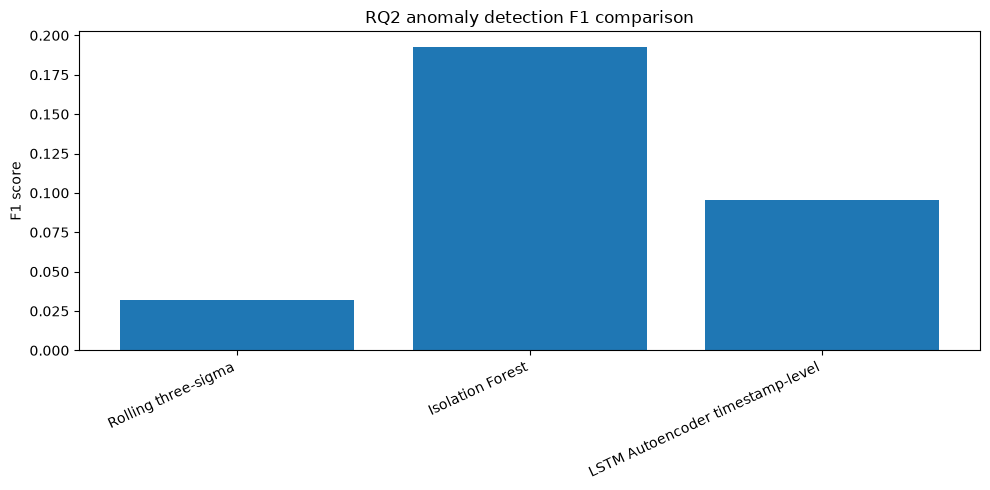

Saved outputs to: ../data/reports/rq2_anomaly_detection


In [14]:
results_df, metrics_by_type_df, mttd_by_event_df, scored_test_df = run_rq2_pipeline()


After running the notebook, use the generated summary table for the final RQ2 write-up:

> RQ2 compared a rolling three-sigma baseline, Isolation Forest, and LSTM Autoencoder using synthetic anomaly injection as ground truth. The training period remained clean, while validation anomalies were used only for threshold calibration and test anomalies were used for final reporting. The best-performing detector was [MODEL], with anomaly-class F1 of [VALUE]. Compared with the three-sigma baseline F1 of [VALUE], this indicates [INTERPRETATION]. Because labels were synthetically injected, the results should be interpreted as controlled detector performance rather than proof of production incident-detection capability.

Focus on anomaly-class precision, recall, F1, and MTTD. Do not use the non-anomaly class F1 as the main RQ2 result.